<a href="https://colab.research.google.com/github/obaidsi/DSP-Filter-Comparison-Important-Algorithms/blob/main/Filters%26ImportantAlgorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Discret Fourier Transform (DFT) Fast fourier Transform (FFT)

---



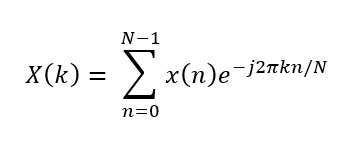

In [72]:
def DFT(signal,N):
    '''Returns DFT without normalization or shift'''
    a = np.expand_dims(np.arange(N),0)
    W = a.transpose() @ a
    W = np.exp(W*-1j*2*np.pi/N)
    X = (signal @ W)
    return X

In [71]:
def FFT(x):
    '''Recursive Cooley-Tukey FFT'''
    N = x.shape[0]
    if((N&(N-1)==0) and N!=0):
        if(N <= 32):
            return DFT(x,N)
        xeven = x[::2]
        xodd = x[1::2]
        Feven = FFT(xeven)
        Fodd = FFT(xodd)
        factor = np.exp(-2j*np.pi*np.arange(0,N)/N)
        return np.concatenate([Feven + factor[:N//2]*Fodd, Feven + factor[N//2:]*Fodd])
    else:
        raise ValueError('not power of 2')

In [73]:
def zero_pad(x):
  x = np.asarray(x)
  N = len(x)
  N2 = 1 << (N-1).bit_length()
  if N == N2:
    return x
  y = np.zeros(N2)
  y[:N] =x
  return y

(0.0, 10.0)

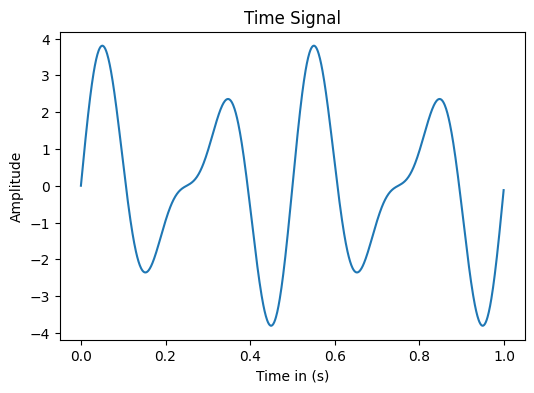

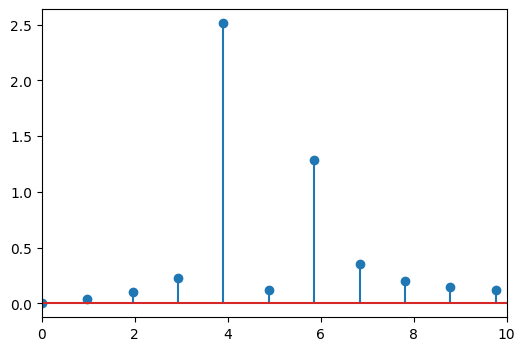

In [74]:
fs = 1000
t = np.arange(0, 1, 1/fs)
x = 2.5 * np.sin(2*np.pi*4*t) + 1.5 * np.sin(2*np.pi*6*t)

plt.figure(figsize =(6, 4))
plt.plot(t, x)
plt.title("Time Signal")
plt.xlabel("Time in (s)")
plt.ylabel("Amplitude")

x = zero_pad(x)
N = len(x)
X = fft_recursive(x)/N
# one side spectrum, and adding the energy back to one side spectrum
X = X[:N//2 +1]
mag = np.abs(X)
mag[1:-1] *= 2

# One side frequency calculation
freqs = np.arange(0, N//2+1) *fs/N

plt.figure(figsize=(6,4))
plt.stem(freqs, mag)
plt.xlim(0, 10)

**Calculating FFT using Numpy libraries**

1100


(0.0, 20.0)

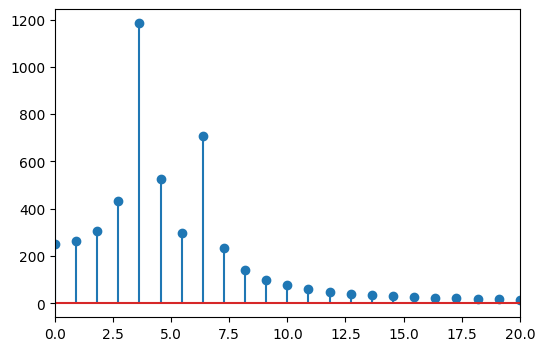

In [75]:
fs = 1000
t = np.arange(0, 1.1, 1/fs)
x = 2.5 * np.sin(2*np.pi*4*t) + 1.5 * np.sin(2*np.pi*6*t)
X = np.fft.rfft(x)
print(len(x))
freqs = np.fft.rfftfreq(len(x), 1/fs)

plt.figure(figsize = (6,4))
plt.stem(freqs, np.abs(X))
plt.xlim(0, 20)

**Spectral Leakage Comparison: Manual FFT vs NumPy FFT**

In this section, the FFT was computed in two ways: first using a manual FFT implementation written from scratch, where zero-padding was applied, and then using NumPy’s FFT, where no zero-padding was applied. The signal duration was increased (e.g., to 1.1 seconds) so that the sinusoidal components no longer completed an integer number of cycles within the FFT window.

In both cases, dominant peaks are still observed near 4 Hz and 6 Hz; however, spectral leakage appears in the frequency domain. This leakage occurs because changing the signal length alters the frequency resolution, causing the signal frequencies to no longer align exactly with discrete FFT bins. As a result, signal energy spreads into neighboring bins.

This demonstrates that spectral leakage is caused by the mismatch between the signal period and the FFT window length, not by the FFT algorithm itself or by the presence or absence of zero-padding. Zero-padding changes the frequency grid density but does not eliminate leakage.

##2) Implementing the Short Time Fourier Transform (STFT) from Scratch

In [76]:
def STFT(signal, window_size, stride, srate):

    starting_positions = np.arange(0,len(signal)-window_size,window_size)# calculate starting positions of each slice (use np.arange)
    slices= [] # placeholder for the slices to be collected

    # obtain signal slices, window each slice and then take it's FFT based on window length and stride length

    #starting_positions =  # starting indices of various slices

    time = np.arange(0,window_size) # time vector accompanying the hanning window (corresponds to n indices)
    win = 0.5 - 0.5*np.cos(2*np.pi*time/window_size) # create the hanning window

    for pos in starting_positions:

        # extract a segment from the signal
        signal_segment = signal[pos:pos+window_size]
        # window the extracted segment
        windowed_segment = signal_segment*win
        # find the spectrum of the windowed segment
        segment_spectrum = FFT(windowed_segment)
        # add it to the growing collection of slices that will constitute the spectrogram
        slices.append(segment_spectrum) # collect spectrum slices

    # convert to numpy array to take advantage of numpy functions that help in obtaining a good plot
    spectrogram = np.asarray(slices)
    # take transpose to have time on the horizontal axis and frequency of the vertical axis while plotting
    spectrogram = spectrogram.transpose()

    print('Audio shape:',signal.shape ,'Sliced audio shape: ', spectrogram.shape)

    return spectrogram

In [77]:
def plot_spectrogram(spec,srate,window_size,audio_duration):

    # Slice out the positive or negative frequencies for now and keep just one half of the spectra
    spectrogram = spec[:window_size // 2 + 1:-1]

    # find absolute value of the spectrum
    S = np.abs(spectrogram)
    # normalize and obtain magnitude spectrum on a decibel(dB) scale
    S = 20 * np.log10(S/ np.max(S))
    # print out the shape of S as a sanity check
    print(S.shape)

    # The spectrum can contain both very large and very small values.
    # Thus, do a log plot of the ratio of the signal divided by the maximum signal
    f, ax = plt.subplots(figsize=(9.6, 4.8))

    upper_time_axis = audio_duration # in seconds
    upper_freq_axis = srate / 2 / 1000 # in kHz
    # plot the spectrogram with the convention: x axis - time in seconds, y axis - frequency in kHz
    ax.imshow(S, origin='lower', cmap='viridis', extent=(0, upper_time_axis, 0, upper_freq_axis))
    ax.axis('tight')
    ax.set_ylabel('Frequency [kHz]')
    ax.set_xlabel('Time [s]');

In [55]:
from IPython.display import Audio
Audio('/content/sample_data/nightingale.wav')

Audio length:  30.511020408163265 seconds


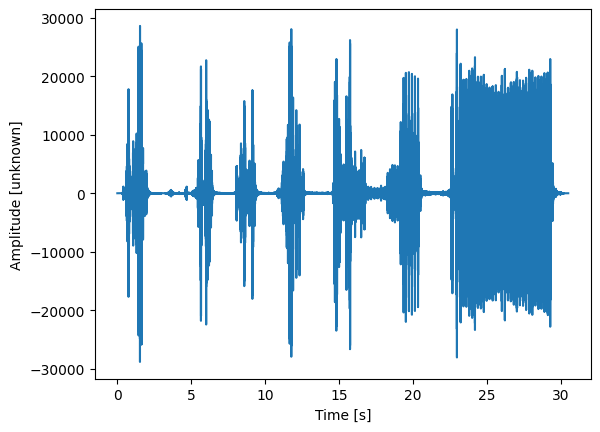

In [78]:
# We load the audio file, which gives us the sampling rate (number of measurements per second)
# as well as audio data as an (N, 2) array—two columns because this is a stereo recording.
from scipy.io import wavfile


srate, audio = wavfile.read('/content/sample_data/nightingale.wav')

# We convert to mono by averaging the left and right channels.
audio_signal = np.mean(audio, axis=1)

N = audio_signal.shape[0]
L = N / srate
print('Audio length: ', L,'seconds')

f, ax = plt.subplots()
ax.plot(np.arange(N) / srate, audio_signal)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude [unknown]');

Audio shape: (1345536,) Sliced audio shape:  (1024, 1313)
(510, 1313)


/tmp/ipython-input-4274448091.py:9: RuntimeWarning: divide by zero encountered in log10
  S = 20 * np.log10(S/ np.max(S))


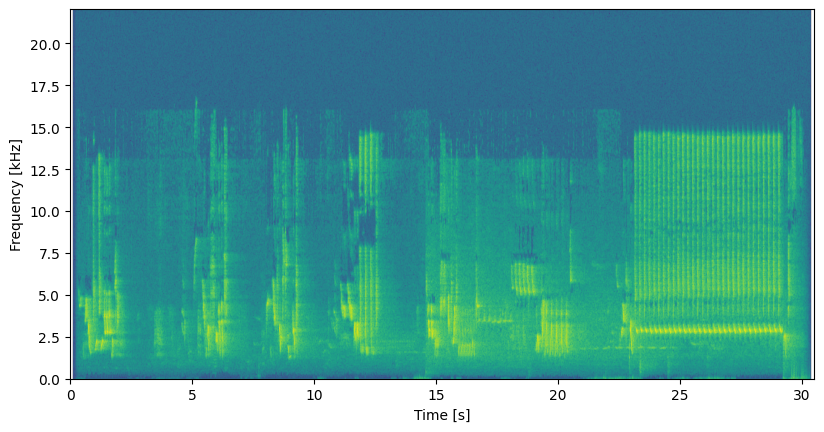

In [79]:
window_size = 1024 # define the window size
stride = 100 # define the stride length
s = STFT(audio_signal, window_size, stride, srate)
plot_spectrogram(s,srate,window_size,L)